In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from joint_plot_grid_nb import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
# define global parameters
sim_kind = 'agent'
infection_type = 'sec'
reg_model = ''

comment = 'no-cell-var'
pnts = 100
virs = vir_prop[1:]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5808/5808 [04:33<00:00, 21.22it/s]


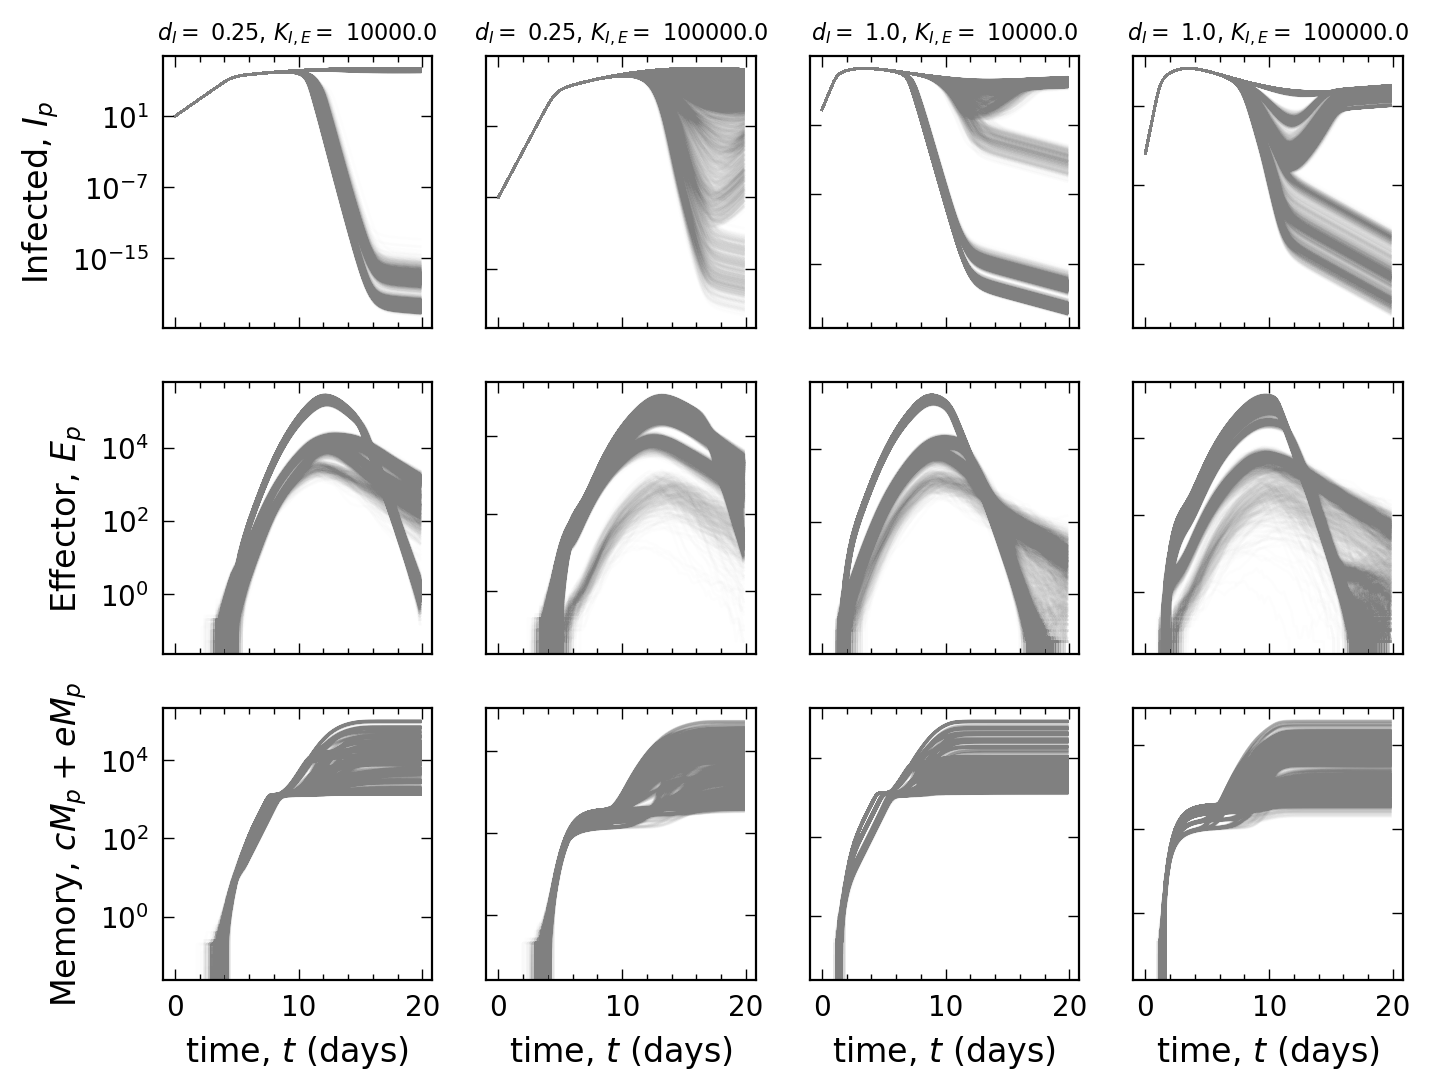

In [6]:
# Plot trends for different networks based on signal correlation
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/cell_time_series/mean/'
d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/cell_time_series/std/'

n = len(virs)
fig, axs = plt.subplots(3, n, figsize=(8, 6), sharex=True)


for file_count, f in enumerate(tqdm(os.listdir(d_mean))):
    if '-100-' not in f or infection_type not in f:
        continue
    dyn_net = np.load(os.path.join(d_mean, f))
    #dyn_std = np.load(os.path.join(d_std, f))
    keep = [i*int(sim_steps/pnts) for i in np.arange(0,pnts)]
    
    for l, (d_I, K_IE) in enumerate(virs):
        dyn_mean = dyn_net[l+1][keep]
    
        pS, sS, pI, sI, Ain, N, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_mean[:,0], dyn_mean[:,-10], dyn_mean[:,1], dyn_mean[:,-9], dyn_mean[:,-8], dyn_mean[:,-7], dyn_mean[:, 4], dyn_mean[:,-6], dyn_mean[:,5], dyn_mean[:, -5], dyn_mean[:,6], dyn_mean[:,-4], dyn_mean[:,7], dyn_mean[:,-3], dyn_mean[:,8], dyn_mean[:,-2], dyn_mean[:,9], dyn_mean[:,-1]
    
        time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
        
    
        # axs[0,l].plot(time, pS, color='grey', 
        #             label = r'Susceptible, $S_p$') #, norm=mpl.colors.LogNorm())
        axs[0,l].plot(time, pI, color='grey',
                    label = r'Infected, $I_p$', alpha = 0.01)
        axs[1,l].plot(time, pE, color='grey',
                    label = r'Effector, $E_p$', alpha = 0.01)
        axs[2,l].plot(time, pcM + peM, color='grey',
                    label = r'Memory, $cM_p+eM_p$', alpha = 0.01)
        # axs[4,l].plot(time, pH, color='grey',
        #             label = r'Inflammation, $H_p$')
        
        axs[0,l].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{I,E} =$ "+str(np.round(K_IE,0)), fontsize = 8)
        
        # if file_count == 0:
        #     axs[0,0].legend(fontsize = 8)
        #     axs[1,0].legend(fontsize = 8)
        #     axs[2,0].legend(fontsize = 8)
        #     axs[3,0].legend(fontsize = 8)
        #     axs[4,0].legend(fontsize = 8)

y_labels = [r'Infected, $I_p$',r'Effector, $E_p$',r'Memory, $cM_p+eM_p$']
for i, ax in enumerate(axs.flat):
    ax.set(xlabel= r"time, $t$ (days)")
    ax.set_yscale('log')
    if i % 4 == 0:
        ax.set(ylabel= y_labels[int(i/4)])

for ax in axs.flat:
    ax.label_outer()
        
#plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5808/5808 [01:51<00:00, 52.30it/s]


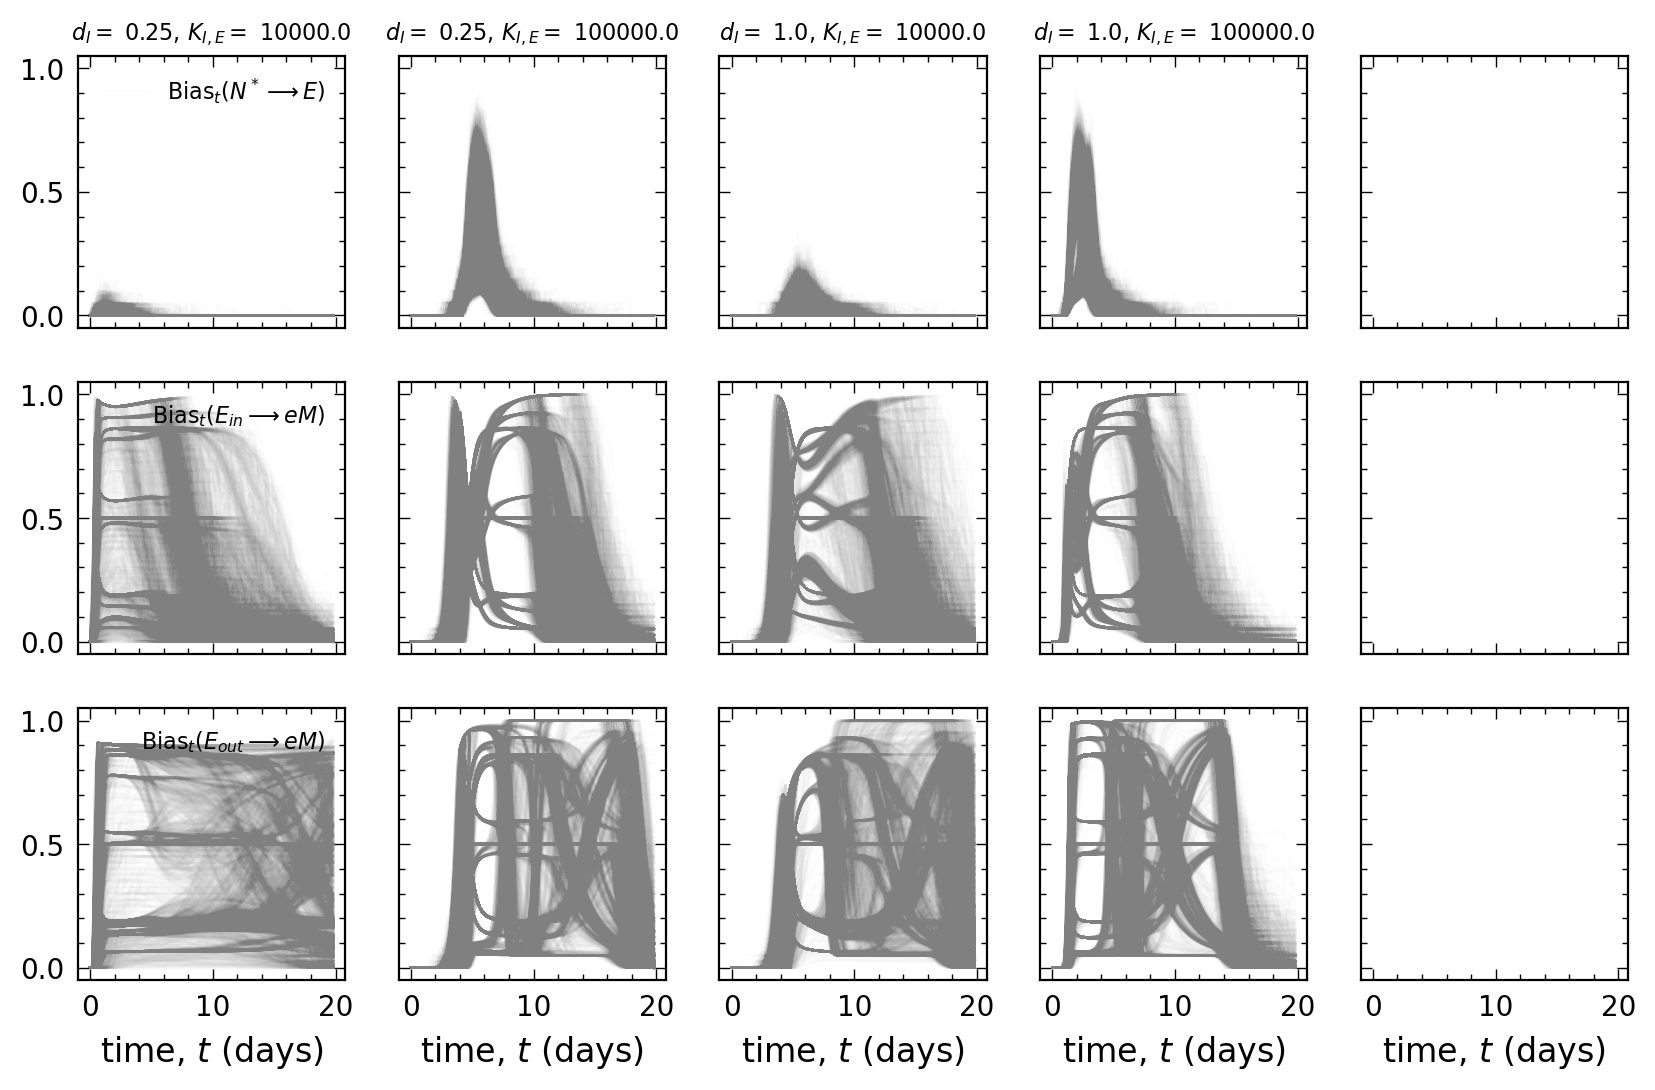

In [7]:
# Plot trends for different networks based on signal correlation
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/diff_bias/mean/'
d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/diff_bias/std/'

n = len(vir_prop)
fig, axs = plt.subplots(3, n, figsize=(10, 6), sharex=True, sharey = True)

for file_count, f in enumerate(tqdm(os.listdir(d_mean))):
    if '-100-' not in f or infection_type not in f:
        continue
    diff_bias_net = np.load(os.path.join(d_mean, f))
    keep = [i*int(sim_steps/pnts) for i in np.arange(0,pnts)]
    
    for l, (d_I, K_IE) in enumerate(virs):
        diff_bias = diff_bias_net[l][keep]
        time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
    
        axs[0,l].plot(time, diff_bias[:,0], color='grey', 
                    label = r'Bias$_t(N^* \longrightarrow E)$', alpha = 0.01)
        axs[1,l].plot(time, diff_bias[:,1], color='grey',
                    label = r'Bias$_t(E_{in} \longrightarrow eM)$', alpha = 0.01)
        axs[2,l].plot(time, diff_bias[:,2], color='grey',
                    label = r'Bias$_t(E_{out} \longrightarrow eM)$', alpha = 0.01)
        
        axs[0,l].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{I,E} =$ "+str(np.round(K_IE,0)), fontsize = 8)
        
        if file_count == 0:
            axs[0,0].legend(fontsize = 8)
            axs[1,0].legend(fontsize = 8)
            axs[2,0].legend(fontsize = 8)
    
for i, ax in enumerate(axs.flat):
    ax.set(xlabel= r"time, $t$ (days)")

for ax in axs.flat:
    ax.label_outer()
        
#plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 18.24it/s]


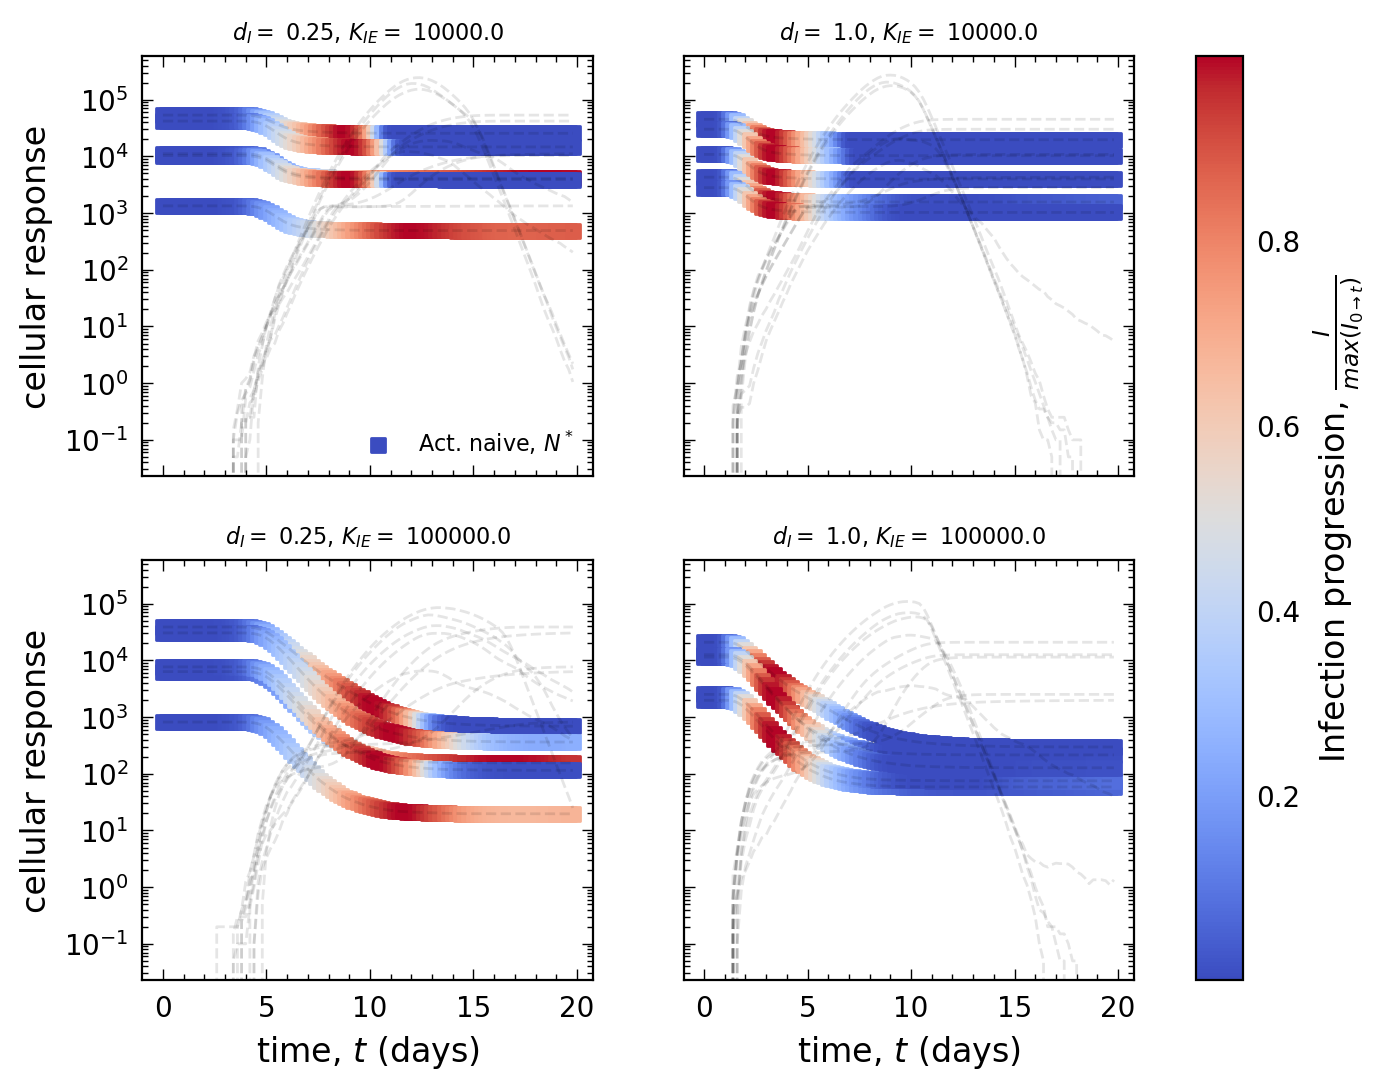

In [4]:
# Plot trends for different networks based on signal correlation
n = len(vir_prop[1:])
n_d_I, n_K_IE = len(np.unique(virs[:,1])), len(np.unique(virs[:,0]))
fig, axs = plt.subplots(n_K_IE, n_d_I, figsize=(8, 6), sharex=True, sharey=True)


for file_count, f in enumerate(tqdm(os.listdir(d_mean)[0:5])):
    if '-100-' not in f or infection_type not in f:
        continue
    dyn_net = np.load(os.path.join(d_mean, f))
    #dyn_std = np.load(os.path.join(d_std, f))
    
    for l, (d_I, K_IE) in enumerate(virs):
        dyn_mean = dyn_net[l+1]
        x,y = l % n_d_I, int(np.floor(l/n_K_IE))
    
        pS, sS, pI, sI, Ain, N, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_mean[:,0], dyn_mean[:,-10], dyn_mean[:,1], dyn_mean[:,-9], dyn_mean[:,-8], dyn_mean[:,-7], dyn_mean[:, 4], dyn_mean[:,-6], dyn_mean[:,5], dyn_mean[:, -5], dyn_mean[:,6], dyn_mean[:,-4], dyn_mean[:,7], dyn_mean[:,-3], dyn_mean[:,8], dyn_mean[:,-2], dyn_mean[:,9], dyn_mean[:,-1]
        
        keep = [i*int(len(pE)/pnts) for i in np.arange(0,pnts)]
        psus = pS[keep]
        naive = N[keep]
        peff = pE[keep]
        pmem = (pcM+peM)[keep]
        p_load = pI[keep]/np.max(pI)
        time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
    
        im = axs[x,y].scatter(time, naive, marker ='s', c =p_load, cmap='coolwarm', 
                    label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
        axs[x,y].plot(time, naive, 'k--', alpha = 0.1)
        axs[x,y].plot(time, peff, 'k--', alpha = 0.1)
        axs[x,y].plot(time, pmem, 'k--', alpha = 0.1)
        axs[x,y].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{IE} =$ "+str(np.round(K_IE,0)), fontsize = 8)
        #axs[x,y].set_title("d_I = {}".format(np.round(d_I,3))+", K_IE = {}".format(K_IE), fontsize = 8)
        
        if x == 0 and y == 0 and file_count == 0:
            axs[x,y].legend(fontsize = 8)
    
for i, ax in enumerate(axs.flat):
    ax.set(xlabel= r"time, $t$ (days)",
           ylabel= 'cellular response')
    ax.set_yscale('log')

for ax in axs.flat:
    ax.label_outer()
    
cb = fig.colorbar(im, ax=axs, orientation='vertical')
cb.set_label(r"Infection progression, $\frac{I}{max(I_{0 \to t})}$")
        
#plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')